<a href="https://colab.research.google.com/github/suryasai99/Object_detection/blob/main/9_NMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import requests
from zipfile import ZipFile

## Download Dependencies

In [2]:
def download_file(url, save_name):
    """
    "Download and save the file."

    arguments:
    url (str): URL path of the file.
    save_name: (str): file path to save the downloaded file.
    """
    file = requests.get(url)
    open(save_name, 'wb').write(file.content)
    print(f"Downloaded {save_name}...")
    return

In [3]:
def unzip(zip_file_path=None):
    """
    "Unzip the file"

    arguments:
    zip_file_path (str): The zipped file path

    """
    try:
        with ZipFile(zip_file_path) as z:
            z.extractall("./")
            print(f"Extracted {zip_file_path}...\n")
    except:
        print("Invalid file")

    return

In [4]:
if not os.path.exists('./decode_nms.zip'):
    download_file(
                  'https://www.dropbox.com/s/3qnxkjcn5oh8fyv/decode_nms.zip?dl=1',
                  'decode_nms.zip'
                 )

    unzip('decode_nms.zip')

Downloaded decode_nms.zip...
Extracted decode_nms.zip...



In [5]:
os.listdir("./")

['.config',
 'fpn.py',
 'Model_checkpoints',
 'decode_nms.zip',
 'test_images',
 'encoder.py',
 'train_boxes.csv',
 'drive',
 'detector.py',
 'sample_data']

In [6]:
!pip install torchinfo

In [7]:
import glob
from dataclasses import dataclass
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torchvision.transforms as T
from torchinfo import summary

from encoder import DataEncoder
from detector import Detector

%matplotlib inline

In [8]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 10)

In [9]:
@dataclass
class Model_Config:
  IMG_SIZE: Iterable[int] = (300, 300, 3)

  BACKBONE_MODEL = "resnet50"
  FPN_CHANNELS: int = 64
  NUM_ANCHORS: int = 4 # Number of anchors

  CLASSES: tuple = ("__background__", "person")

  if torch.cuda.is_available():
      torch.backends.cudnn.deterministic = True
      torch.backends.cudnn.benchmark = True

      DEVICE: str = "cuda"

  else:
      DEVICE: str = "cpu"

## Load Test Images and Labels


In [10]:
image_dir = "test_images"
label_files = glob.glob(os.path.join(image_dir, "*.txt"))

In [11]:
def load_test_image_targets(label_files):

    test_image_labels = []
    test_image_boxes = []
    test_image_paths = []

    image_paths = []
    labels = []


    for file in label_files:
        with open(file,'r') as ann:
            lines = ann.readlines()

        dic = {
            'bbox': [],
            'class': []
        }

        for line in lines:
            splited = line.strip().split()
            dic['class'].append(int(splited[0]))
            dic['bbox'].append([float(splited[1]), float(splited[2]), float(splited[3]), float(splited[4])])

        image_file_path = file.replace(".txt", ".png")
        image_paths.append(image_file_path)
        labels.append(dic)

    return image_paths, labels

In [12]:
image_paths, labels = load_test_image_targets(label_files)

for i , img_path in enumerate(image_paths):
    print('{}:'.format(img_path))
    print(labels[i])
    print()

test_images/PennPed00066.png:
{'bbox': [[11.0, 76.0, 128.0, 365.0], [265.0, 33.0, 398.0, 312.0], [76.0, 30.0, 189.0, 345.0]], 'class': [1, 1, 1]}

test_images/PennPed00025.png:
{'bbox': [[72.0, 34.0, 216.0, 310.0], [189.0, 151.0, 276.0, 304.0], [390.0, 2.0, 421.0, 71.0]], 'class': [1, 1, 1]}

test_images/FudanPed00008.png:
{'bbox': [[228.0, 158.0, 370.0, 436.0], [39.0, 179.0, 115.0, 363.0]], 'class': [1, 1]}



## Inference and Decoding

In [13]:
def load_model(path, load_weights=False, verbose = False, config=Model_Config(), **kwargs):


    input_height, input_width = config.IMG_SIZE[:2]


    # Load model architecture.
    model = Detector(backbone=config.BACKBONE_MODEL,
                     num_classes=len(config.CLASSES),
                     num_anchors=config.NUM_ANCHORS,
                     fpn_channels=config.FPN_CHANNELS)

    # Load Model's state dictionary.
    model.load_state_dict(torch.load(path, map_location=config.DEVICE))

    model = model.to(config.DEVICE)

    if verbose:
        print(summary(model,
                      input_size=(1,3,input_height, input_width),
                      device=config.DEVICE,
                      row_settings=["var_names"])
             )

    return model

In [14]:
model_config = Model_Config()
ckpt_path = os.path.join("Model_checkpoints", "Detector_best.pth")
model = load_model(ckpt_path, config=model_config)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 101MB/s] 


In [15]:
# Define transforms.
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

mean = torch.Tensor(mean)
std = torch.Tensor(std)

common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std)])


img_size = model_config.IMG_SIZE[:2]
test_images = []

for image_file in image_paths:
    image = cv2.imread(image_file)[..., ::-1]
    image_resize = cv2.resize(image, (img_size[1], img_size[0]), cv2.INTER_CUBIC)
    img_transforms = common_transforms(image_resize)
    test_images.append(img_transforms)


batch_inputs = torch.stack(test_images).to(model_config.DEVICE)

In [16]:
model.eval()

with torch.no_grad():
    batch_predictions = model(batch_inputs)

In [17]:
print(f"Regression head output shape: {batch_predictions[0].shape}")
print(f"Classification head output shape: {batch_predictions[1].shape}")

Regression head output shape: torch.Size([3, 7756, 4])
Classification head output shape: torch.Size([3, 7756, 2])


In [18]:
encoder = DataEncoder(img_size, model_config.CLASSES)
nms_threshold = 0.5
score_threshold = 0.95
soft_nms_sigma = 0.5

prediction = []

print("-------"*21)
for i in range(batch_predictions[0].shape[0]):

    # decode for each image
    preds = encoder.decode(
        loc_pred=batch_predictions[0][i],
        cls_pred=batch_predictions[1][i],
        device=model_config.DEVICE,
        nms_threshold=nms_threshold,
        score_threshold=score_threshold,

        ).cpu().numpy()

    pred_dict = dict(
                      bbox     = preds[:,:4],
                      conf     = preds[:,4],
                      class_id = preds[:,5])

    print(pred_dict)
    print("-------"*21)
    prediction.append(pred_dict)

---------------------------------------------------------------------------------------------------------------------------------------------------
{'bbox': array([[198.94528 ,  38.729805, 265.18597 , 251.44916 ],
       [ 16.166496,  60.01409 ,  84.270966, 298.74057 ],
       [ 45.17341 ,  29.095207, 113.630196, 275.63043 ]], dtype=float32), 'conf': array([0.9990779, 0.9765707, 0.9632555], dtype=float32), 'class_id': array([1., 1., 1.], dtype=float32)}
---------------------------------------------------------------------------------------------------------------------------------------------------
{'bbox': array([[ 57.837627,  46.512604, 142.84074 , 283.83893 ],
       [121.38649 , 120.29893 , 182.48987 , 276.53897 ]], dtype=float32), 'conf': array([0.99854636, 0.99108255], dtype=float32), 'class_id': array([1., 1.], dtype=float32)}
---------------------------------------------------------------------------------------------------------------------------------------------------
{'bbox

## Visualising Detections

In [19]:
class VisualizeBBox:
    def __init__(self, img_paths, predictions, labels,
                 img_size=model_config.IMG_SIZE[:2],
                 class_names=model_config.CLASSES, fig_size=(14, 21)):
        self.img_path = img_paths
        self.predictions = predictions
        self.labels = labels
        self.model_input_size = img_size

        self.class_names = class_names
        self.fig_size = fig_size

        self.gt_color = (0, 0, 255)
        self.pred_color = (0, 255, 0)

        self.rows = len(img_paths)
        self.columns = 2

    def rescale_bbox(self, bboxes, img_size):
        h_ratio = img_size[0]/self.model_input_size[0]
        w_ratio = img_size[1]/self.model_input_size[1]

        # Scale bounding boxes size according to original image size
        bboxes[:, 0] = np.maximum(0,   (bboxes[:, 0] * w_ratio))
        bboxes[:, 1] = np.maximum(0,   (bboxes[:, 1] * h_ratio))
        bboxes[:, 2] = np.minimum(img_size[1], (bboxes[:, 2] * w_ratio))
        bboxes[:, 3] = np.minimum(img_size[0], (bboxes[:, 3] * h_ratio))

        return bboxes

    def draw_bbox(self, image, boxes, labels=None, scores=None,
                  color=(255, 0, 0), thickness=1):
        boxes = np.asarray(boxes, dtype=np.int32)
        for idx, box in enumerate(boxes):
            xmin = box[0]
            ymin = box[1]
            xmax = box[2]
            ymax = box[3]

            image = cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)

            if labels is not None:
                display_text = labels[idx]
                display_text = f"{self.class_names[int(labels[idx])]}"

                if scores is not None:
                    display_text = display_text + ": " + str(round(100*scores[idx],2))+"%"

                (text_width, text_height), _ = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)

                cv2.rectangle(image, (xmin, ymin - int(0.9 * text_height)), (xmin + int(0.4*text_width), ymin), color, -1)


                image = cv2.putText(
                    image,
                    display_text,
                    (xmin, ymin - int(0.3 * text_height)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.4,
                    (0, 0, 0),
                    1,
                )
        return image

    @staticmethod
    def bgr_rgb(img):
        return img[:, :, ::-1]

    def show(self):
        # Define subplots
        fig, axes = plt.subplots(
            nrows=self.rows,
            ncols=self.columns,
            figsize=self.fig_size,
        )

        list_axes = list(axes.flat)

        count = 0
        while count < len(list_axes):
            img_idx = count // 2
            image = cv2.imread(self.img_path[img_idx])


            # add ground truth bounding box
            bbox = self.labels[img_idx]['bbox']
            class_label = self.labels[img_idx]['class']
            score = None

            img_gt = self.draw_bbox(image.copy(), bbox, class_label, score,
                                    color=self.gt_color, thickness=2)

            list_axes[count].imshow(self.bgr_rgb(img_gt))

            count += 1

            # add prediction plot
            bbox = self.predictions[img_idx]["bbox"]
            class_label = self.predictions[img_idx]["class_id"]
            score = self.predictions[img_idx]["conf"]

            bbox = self.rescale_bbox(bbox.copy(), image.shape[:2])

            img_pred = self.draw_bbox(image.copy(), bbox, class_label, score,
                                      color=self.pred_color, thickness=2)
            list_axes[count].imshow(self.bgr_rgb(img_pred))

            count += 1

        fig.suptitle("Ground-Truths vs Predictions", fontsize=20)
        plt.show()



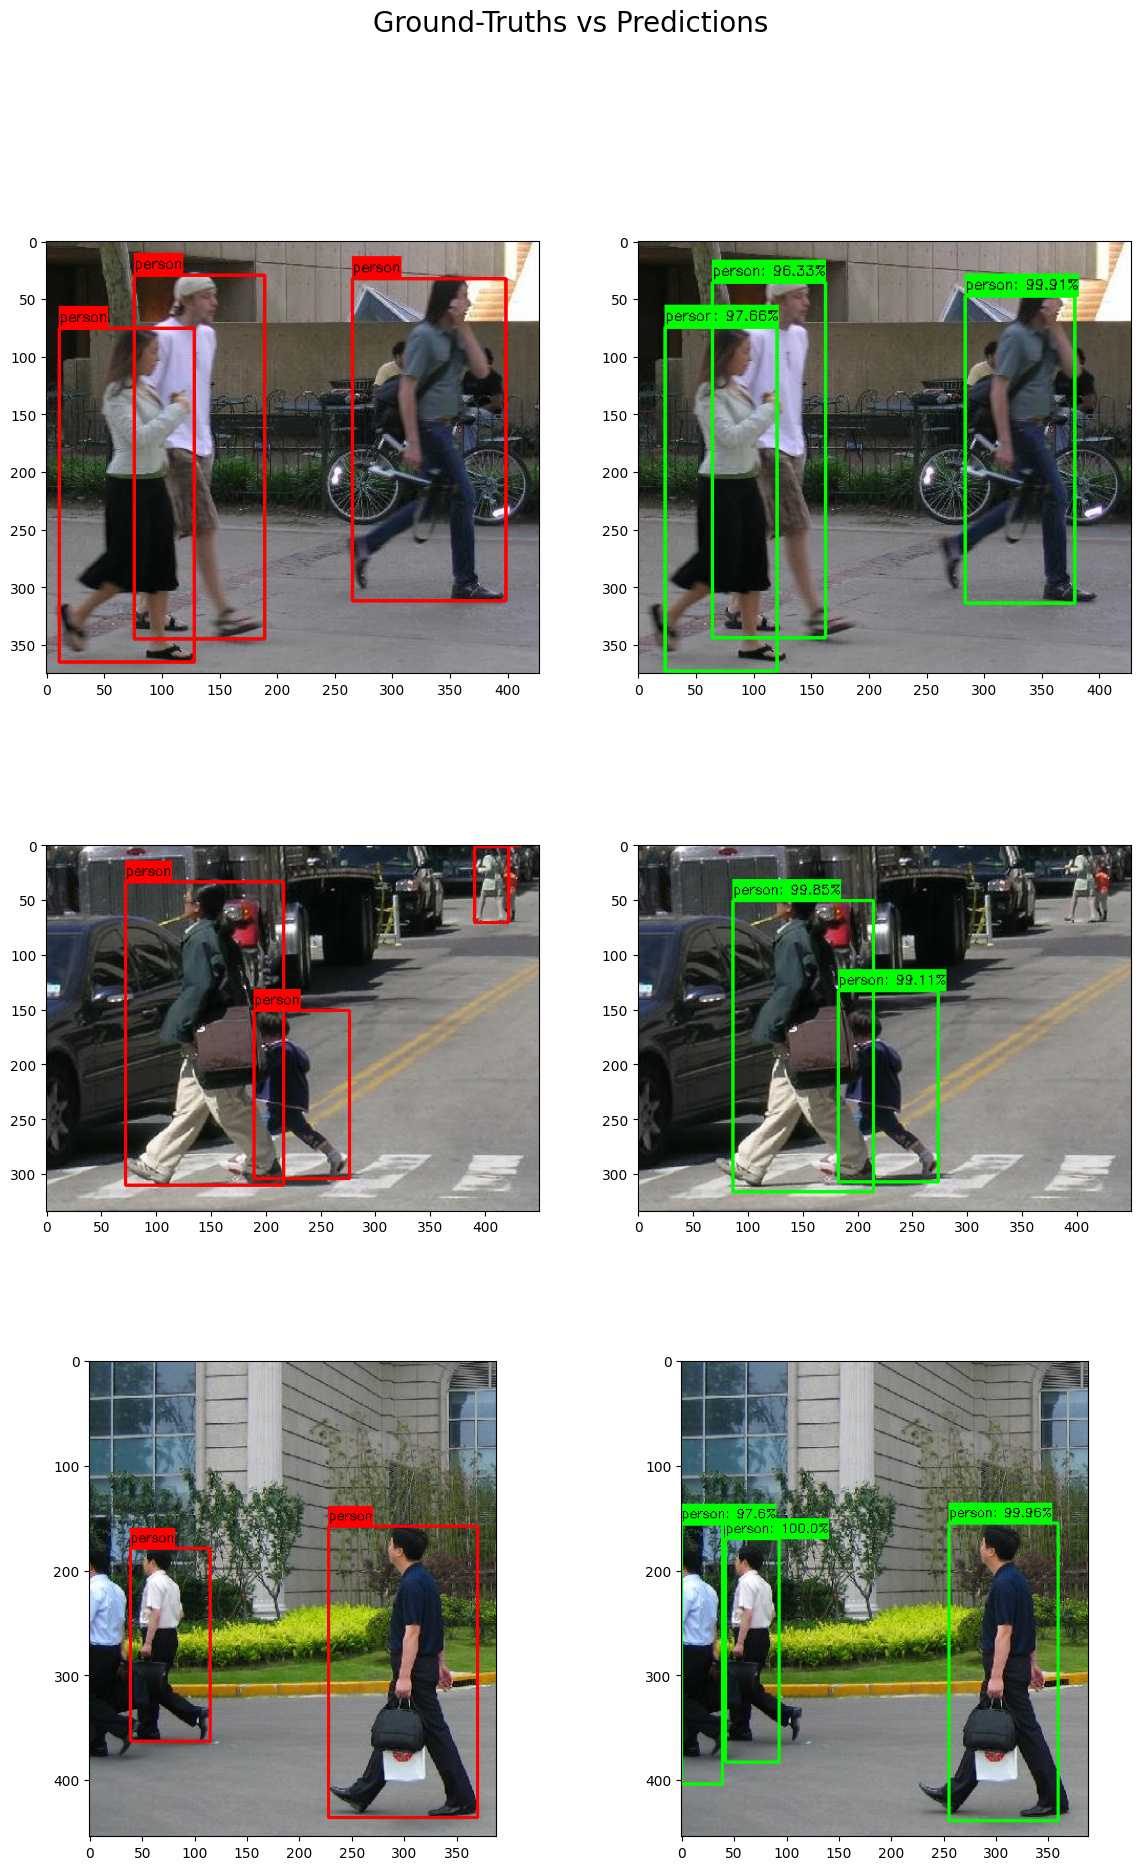

In [20]:
viz = VisualizeBBox(image_paths, prediction, labels)
viz.show()